#### Sunwoo Lee
#### 7th April 2026

# Assignment 5: Forecasting Weekly Sea Surface Height Using EOF, ARMA/ARIMA, and Kalman Filtering 

## Imports

In [5]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from numpy.linalg import svd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.structural import UnobservedComponents

## Global Variables

In [7]:
data = sio.loadmat("weeklyData.mat")

## Global Functions

In [325]:
def graph_color(name):
    if name.lower() == "central":
        return "#1E88E5"
    elif name.lower() == "coastal":
        return "#FFC107"
    elif name.lower() == "offshore":
        return "#D81B60"
    else:
        return np.nan

def plot_all_ts(central, coastal, offshore):
    plt.figure(figsize=(10, 8))
    plt.suptitle(f"Time Series Plot", weight='bold')

    plt.subplot(2, 2, 1)
    plt.plot(central, color=graph_color("central"))
    plt.title("Central Time Series")
    plt.ylabel("SSH")

    plt.subplot(2, 2, 2)
    plt.plot(coastal, color=graph_color("coastal"))
    plt.title("Coastal Time Series")
    plt.ylabel("SSH")

    plt.subplot(2, 2, 3)
    plt.plot(offshore, color=graph_color("offshore"))
    plt.title("Offshore Time Series")
    plt.ylabel("SSH")

    plt.tight_layout()
    plt.show()

def plot_all_decomps(ts_dict, decomp_dict):
    fig = plt.figure(figsize=(14, 16), constrained_layout=True)
    fig.suptitle("Decomposed Time Series", weight='bold')

    # Outer grid (2x2)
    outer_gs = fig.add_gridspec(2, 2)

    positions = {
        "Central": (0, 0),
        "Coastal": (0, 1),
        "Offshore": (1, 0)
    }

    for name, (r, c) in positions.items():
        ts = ts_dict[name]
        decomp = decomp_dict[name]

        # Inner grid (4x1 inside each outer cell)
        inner_gs = outer_gs[r, c].subgridspec(4, 1)

        ax1 = fig.add_subplot(inner_gs[0])
        ax1.plot(ts, color=graph_color(name))
        ax1.set_title(f"\n{name} Time Series\n\nOriginal")
        ax1.set_ylabel("SSH")
        plt.grid()

        ax2 = fig.add_subplot(inner_gs[1])
        ax2.plot(decomp.trend, color=graph_color(name))
        ax2.set_title("Trend")
        plt.grid()

        ax3 = fig.add_subplot(inner_gs[2])
        ax3.plot(decomp.seasonal, color=graph_color(name))
        ax3.set_title("Seasonal")
        plt.grid()

        ax4 = fig.add_subplot(inner_gs[3])
        ax4.plot(decomp.resid, color=graph_color(name))
        ax4.set_title("Residual")
        ax4.set_xlabel("Time (weeks)")
        plt.grid()
        
    plt.show()

## Task 1: Load and Explore the Weekly SSH Data

### 1.1 Converting Cell Array to 3D Numpy Array

In [9]:
# Extracting the cell array
weeklyData = data['weeklyData']

# Flatten the cell array
weeklyData = weeklyData.flatten()

# Number of time steps
T = len(weeklyData)

# Get spatial dimensions from first week
Nlat, Nlon = weeklyData[0].shape
M = Nlat * Nlon

# Initialize 3D array
SSH = np.zeros((T, Nlat, Nlon))

# Fill the array
for t in range(T):
    SSH[t, :, :] = weeklyData[t]
    
print(f"Final dataset shape: {SSH.shape} (time × lat × lon)")

Final dataset shape: (940, 541, 385) (time × lat × lon)


### 1.2 Plotting 3 Different Week of SSH Maps

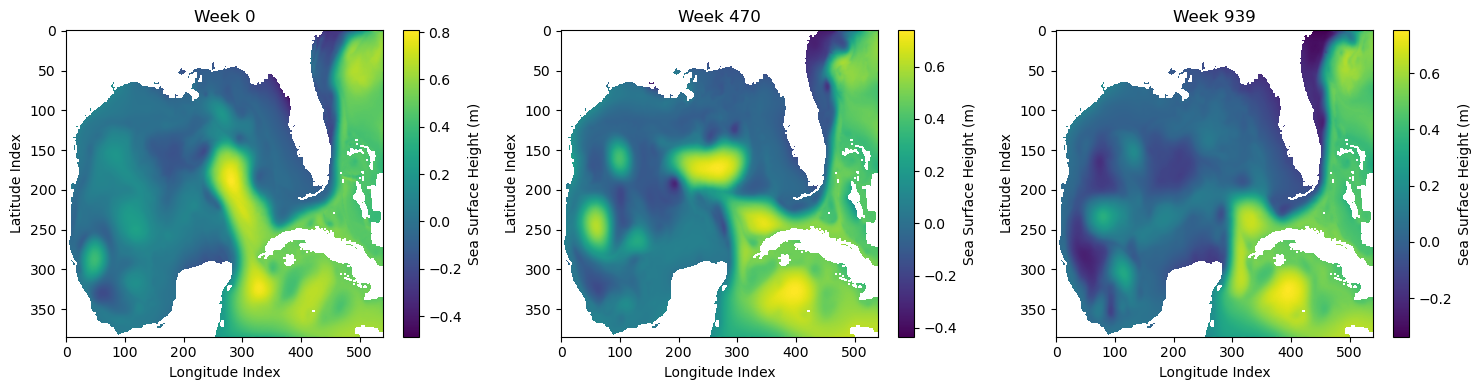

In [17]:
# Choose weeks: start, middle, end
weeks_to_plot = [0, T // 2, T - 1]

plt.figure(figsize=(15, 4))

for i, t in enumerate(weeks_to_plot):
    plt.subplot(1, 3, i+1)
    rotated_img = np.rot90(SSH[t, :, :], k=1)
    plt.imshow(rotated_img, origin='lower', aspect='auto')
    plt.colorbar(label='Sea Surface Height (m)')
    plt.title(f'Week {t}')
    plt.xlabel('Longitude Index')
    plt.ylabel('Latitude Index')
    plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### 1.3 Extracting SSH Times Series at 3 Locations

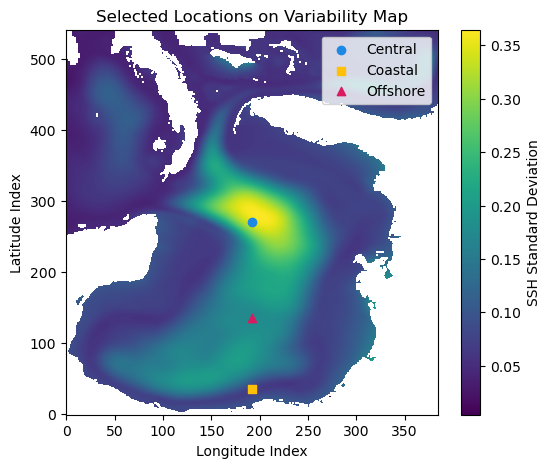

In [241]:
# Standard deviation over time at each grid point
std_map = np.std(SSH, axis=0)

# Define central location
central = (Nlat // 2, Nlon // 2) # middle of the grid

# Define coastal location
coastal = (Nlat // 15, Nlon // 2) # near the edge

# Define offshore location
offshore = (Nlat // 4, Nlon // 2) # somewhere between the 2

plt.figure(figsize=(6, 5))

plt.imshow(std_map, origin='lower', aspect='auto')
plt.colorbar(label='SSH Standard Deviation')

# Plot selected points
plt.scatter(central[1], central[0], marker='o', label='Central', color=graph_color("central"))
plt.scatter(coastal[1], coastal[0], marker='s', label='Coastal', color=graph_color("coastal"))
plt.scatter(offshore[1], offshore[0], marker='^', label='Offshore', color=graph_color("offshore"))

plt.legend()
plt.title('Selected Locations on Variability Map')
plt.xlabel('Longitude Index')
plt.ylabel('Latitude Index')

plt.show()

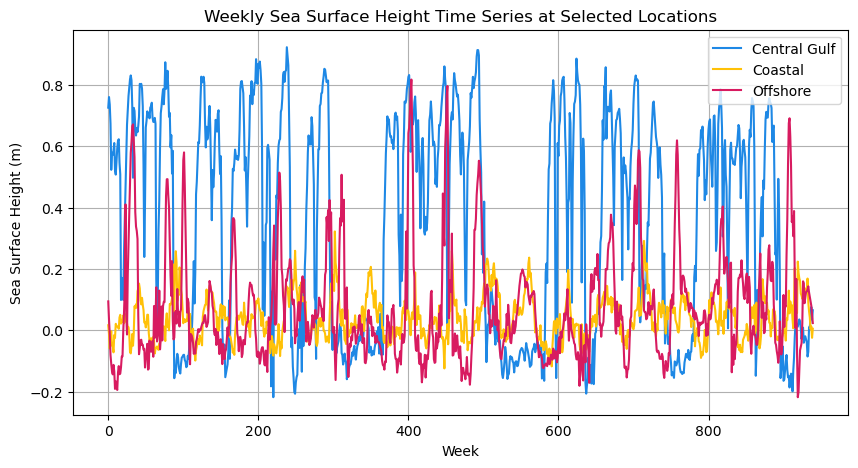

In [243]:
# Extract time series
ts_central = SSH[:, central[0], central[1]]
ts_coastal = SSH[:, coastal[0], coastal[1]]
ts_offshore = SSH[:, offshore[0], offshore[1]]

plt.figure(figsize=(10, 5))

plt.plot(ts_central, label='Central Gulf', color=graph_color("central"))
plt.plot(ts_coastal, label='Coastal', color=graph_color("coastal"))
plt.plot(ts_offshore, label='Offshore', color=graph_color("offshore"))

plt.title('Weekly Sea Surface Height Time Series at Selected Locations')
plt.xlabel('Week')
plt.ylabel('Sea Surface Height (m)')
plt.legend()
plt.grid()

plt.show()

### Discussion

In [130]:
print(f"Central Time Series Mean:  {np.mean(ts_central):.5f} and STD: {np.std(ts_central):.5f}")
print(f"Coastal Time Series Mean:  {np.mean(ts_coastal):.5f} and STD: {np.std(ts_coastal):.5f}")
print(f"Offshore Time Series Mean: {np.mean(ts_offshore):.5f} and STD: {np.std(ts_offshore):.5f}")

Central Time Series Mean:  0.35816 and STD: 0.34797
Coastal Time Series Mean:  0.04057 and STD: 0.06946
Offshore Time Series Mean: 0.07423 and STD: 0.17606


In [152]:
print(f"Correlation between Central vs Coastal: {np.corrcoef(ts_central, ts_coastal)[0][1]:.5f}")
print(f"Correlation between Central vs Offshore: {np.corrcoef(ts_central, ts_offshore)[0][1]:.5f}")
print(f"Correlation between Coastal vs Offshore: {np.corrcoef(ts_coastal, ts_offshore)[0][1]:.5f}")

Correlation between Central vs Coastal: -0.23072
Correlation between Central vs Offshore: 0.05370
Correlation between Coastal vs Offshore: 0.08514


1. The dataset is structured as a 3D array of size (940, 541, 385), representing time (in weeks), latitude, and longitude. Each time step corresponds to a 2D sea surface height (SSH) map, while each grid point forms a time series.

2. The selected locations show different behaviors in both variability and correlation. The central location has the highest variability, the offshore location is moderate, and the coastal location is relatively stable, with much lower variability. Correlation between locations are weak, except for a slight negative relationship (-0.231) between the central and coastal points. These results suggest that SSH variability is largely driven by localized processes rather than a connected basin wide signal.

3. The central time series exhibits strong oscillatory behavior with large fluctuations, while the offshore series show a mix of oscillations and irregular variability. The coastal series is dominated by low amplitude, noise-like behavior with no clear periodicity. No significant long term trend is observed in any of the locations.

## Task 2: Preprocess the Weekly SSH Data

### 2.1 Removing Temporal Mean

In [188]:
# Removing Temporal Mean
SSH_2d = SSH.reshape(T, -1)
mean_field = np.nanmean(SSH_2d, axis=0)
SSH_anom = SSH_2d - mean_field

C:\Users\swlee\AppData\Local\Temp\ipykernel_6644\3180718487.py:3: RuntimeWarning: Mean of empty slice
  mean_field = np.nanmean(SSH_2d, axis=0)


### 2.2 Handling Missing Values

In [191]:
# Drop columns that are all NAN
valid_mask = ~np.all(np.isnan(SSH_anom), axis=0)
SSH_valid = SSH_anom[:, valid_mask]

# Zero-Fill Remaining NANs
SSH_clean = np.nan_to_num(SSH_valid, nan=0.0)
print(f"Valid Spatial Points: {SSH_clean.shape[1]} / {SSH_2d.shape[1]}")

Valid Spatial Points: 150571 / 208285


### 2.3 Check for Trend / Seasonality

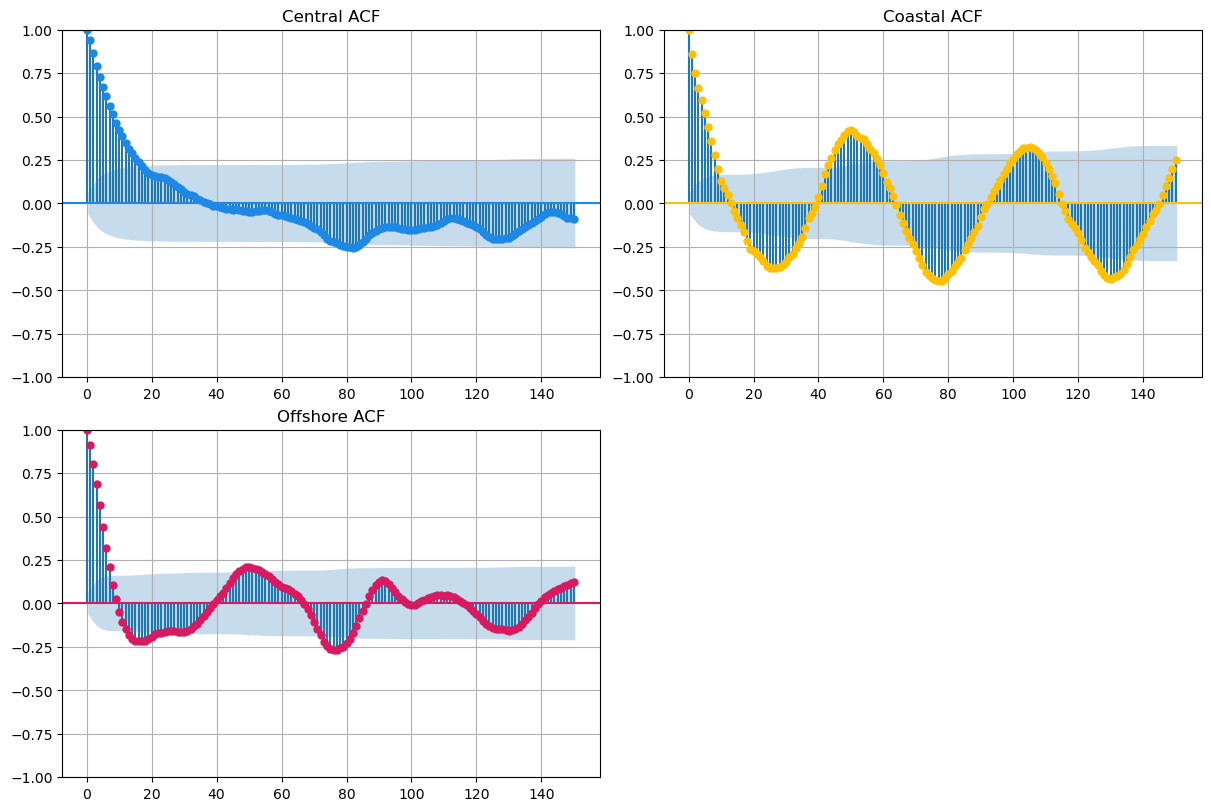

In [339]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Central
plot_acf(ts_central, lags=150, ax=axes[0, 0], color=graph_color("central"))
axes[0, 0].set_title("Central ACF")

# Coastal
plot_acf(ts_coastal, lags=150, ax=axes[0, 1], color=graph_color("coastal"))
axes[0, 1].set_title("Coastal ACF")

# Offshore
plot_acf(ts_offshore, lags=150, ax=axes[1, 0], color=graph_color("offshore"))
axes[1, 0].set_title("Offshore ACF")

# Empty bottom-right plot
axes[1, 1].axis("off")

for ax in axes.flat:
    ax.grid(True)

plt.show()

### 2.4 Decompose Time Series

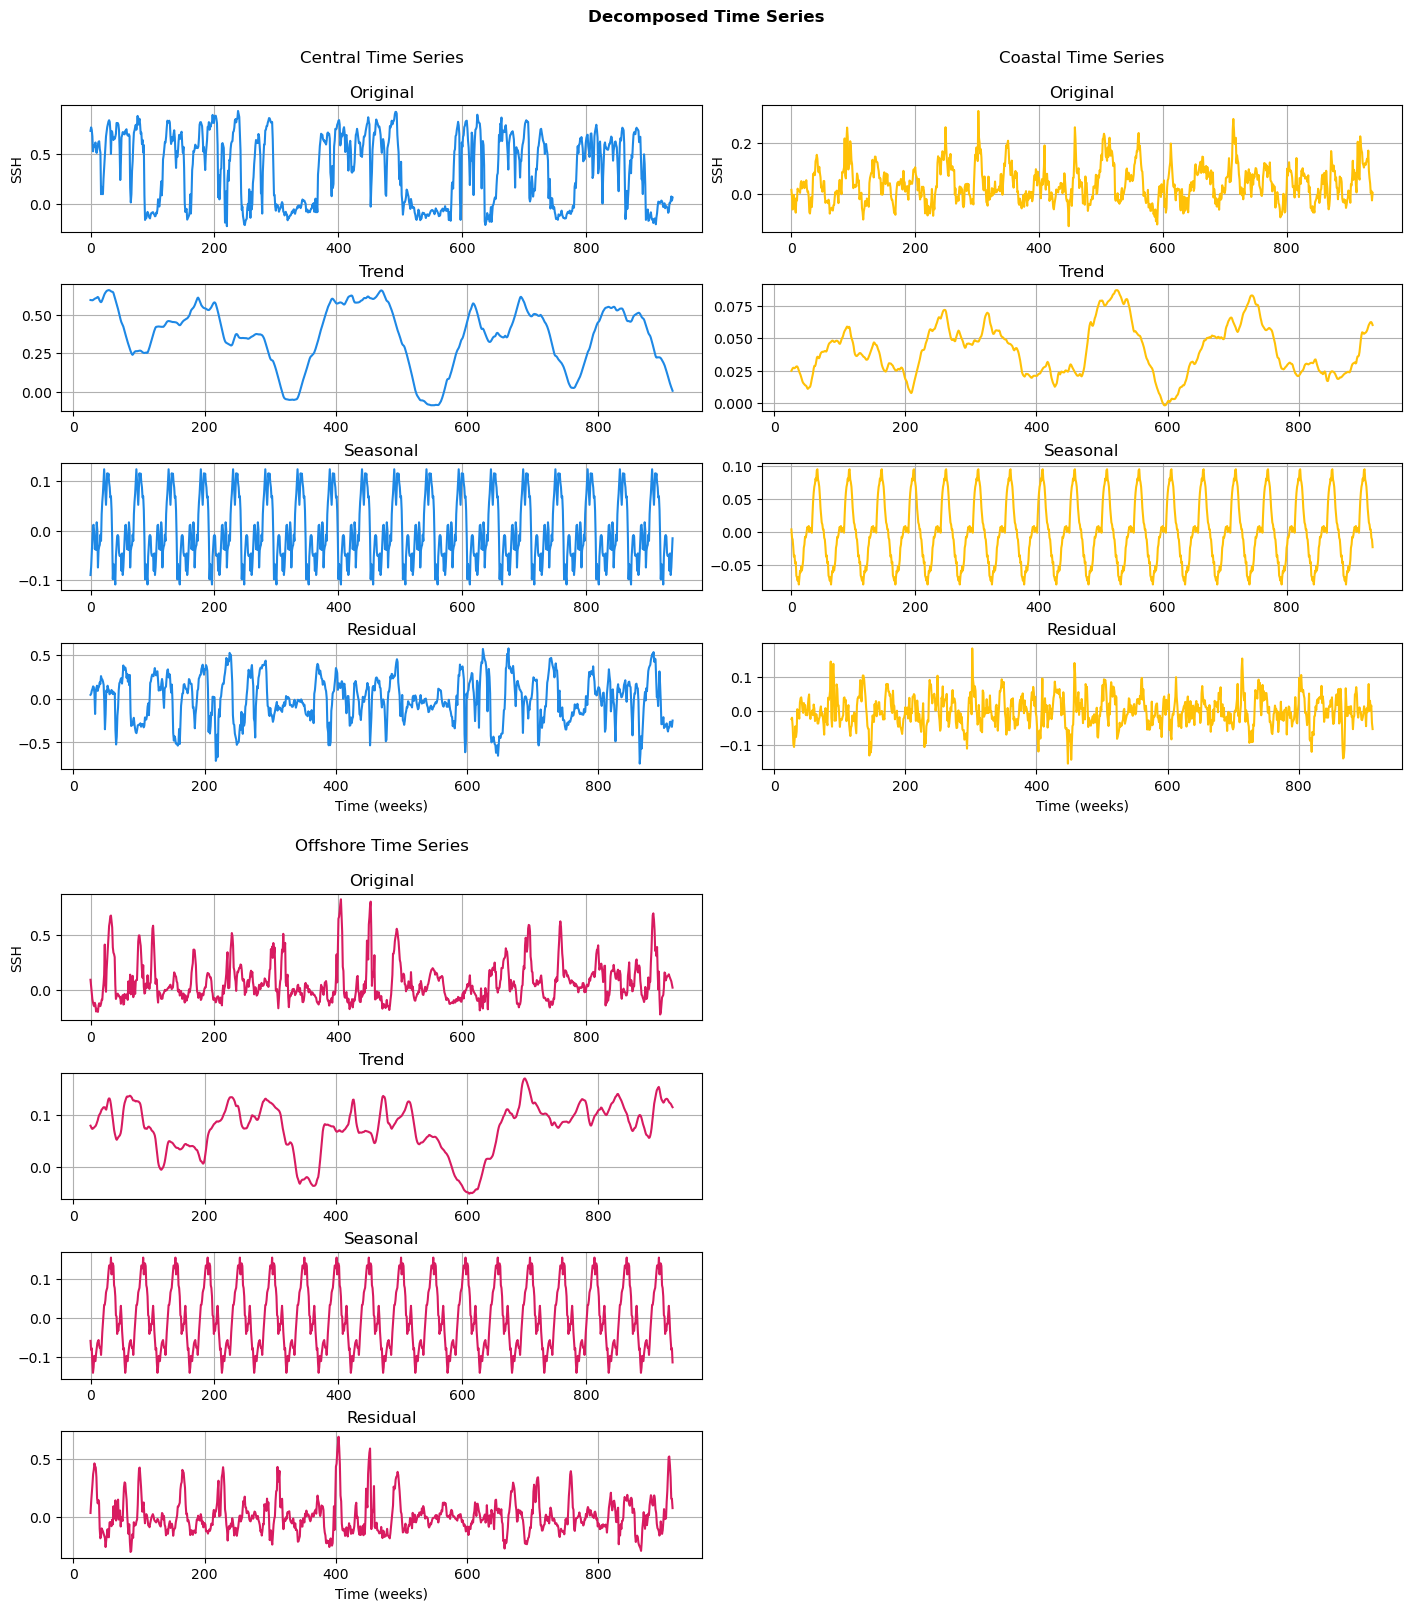

In [327]:
decomp_central = seasonal_decompose(ts_central, period=52, model='additive')
decomp_coastal = seasonal_decompose(ts_coastal, period=52, model='additive')
decomp_offshore = seasonal_decompose(ts_offshore, period=52, model='additive')

plot_all_decomps({
    "Central": ts_central,
    "Coastal": ts_coastal,
    "Offshore": ts_offshore
}, {
    "Central": decomp_central,
    "Coastal": decomp_coastal,
    "Offshore": decomp_offshore
})

### Discussion

The weekly SSH series do not appear stationary. The decomposition plots show clear time varying trends in all three locations, and the ACF plots decay slowly, indicating persistence and non stationarity. Additionally, the presence of strong seasonal oscillations, particularly in coastal and offshore series, further violates the assumption of constant statistical properties over time.

Detrending may be needed as the trend components show gradual changes in the mean SSH over time, expecially in the central and offshore locations. Since ARMA models assume a constant mean, retaining these trends would bias the model and reduce forecasting accuracy. Removing the trend isolates the short term dynamics that ARMA is designed to capture.

Removing seasonal structure is important since the decomposition and ACF plots show a clear repeating pattern at approximately 52 week intervals, corresponding to an annual cycle. This periodic behavior introduces long range dependence that standard ARMA models cannot efficiently represent. By removing the seasonal component, the remaining series becomes more suitable for ARMA modeling.

Residual analysis is useful because it reveals whether the remaining signal behaves like random noise. In the plots, the residuals appear more centered around zero and lack strong visible structure compared to the original series, although some variability remains. This helps confirm whether the preprocessing was sufficient before applying forecasting models.

## Task 3: Apply EOF Analysis

### 3.1 Apply Singular Value Decomposition (SVD)

In [354]:
# SSH was already reshaped and temporal mean was already taken out
print("Performing SVD")
U, S, VT = svd(SSH_clean, full_matrices=False)

Performing SVD


### 3.2 Retain Top 10 EOF Modes and Extract Corresponding PCs

In [365]:
k = 10

EOFs = VT[:k, :]
PCs = U[:, :k] * S[:k]

print(f"PCs Shape: {PCs.shape}")

explained = (S**2) / np.sum(S**2)
print("Top-10 explained variance (%):",
      np.round(explained[:10] * 100, 2))
cumm_var = np.cumsum(explained)

PCs Shape: (940, 10)
Top-10 explained variance (%): [17.24 13.65  7.55  5.76  4.29  3.75  3.15  2.65  2.42  2.32]


### 3.3 Plotting EOF Spatial Modes

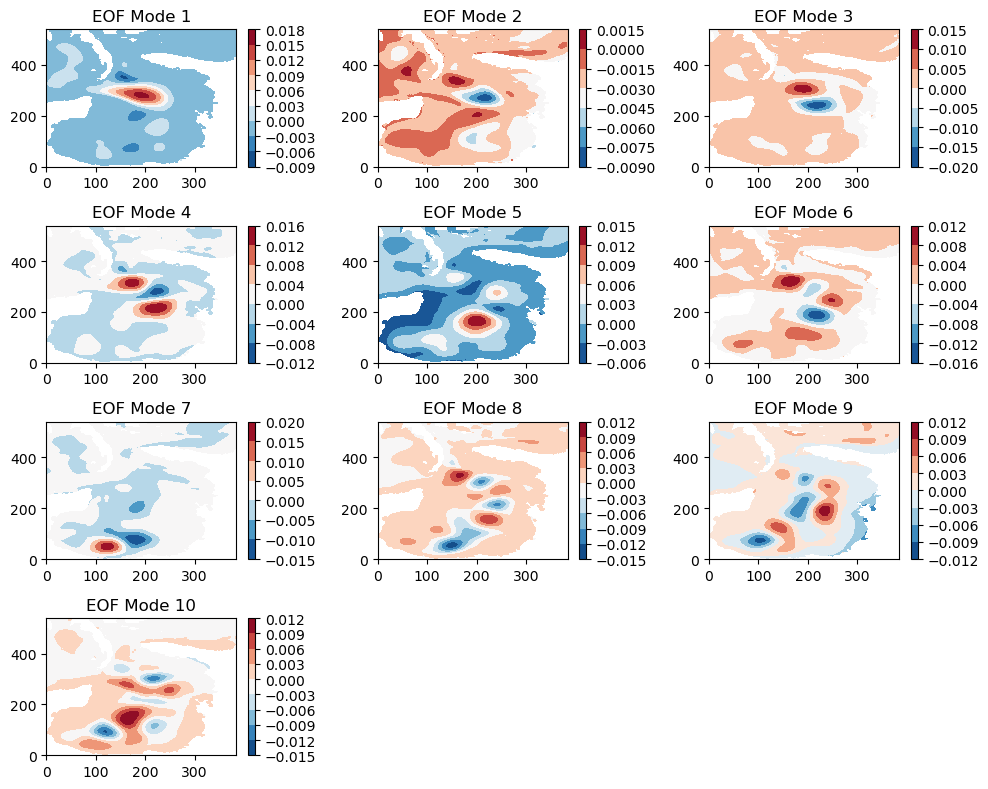

In [405]:
lat = np.arange(Nlat)
lon = np.arange(Nlon)
Lon, Lat = np.meshgrid(lon, lat)

plt.figure(figsize=(10,8))

for i in range(k):
    eof_map = np.full(M, np.nan)
    eof_map[valid_mask] = EOFs[i]
    eof_map = eof_map.reshape(Nlat, Nlon)

    plt.subplot(4, 3, i+1)
    plt.contourf(Lon, Lat, eof_map, cmap='RdBu_r')
    plt.title(f'EOF Mode {i+1}')
    plt.colorbar()

plt.tight_layout()
plt.show()

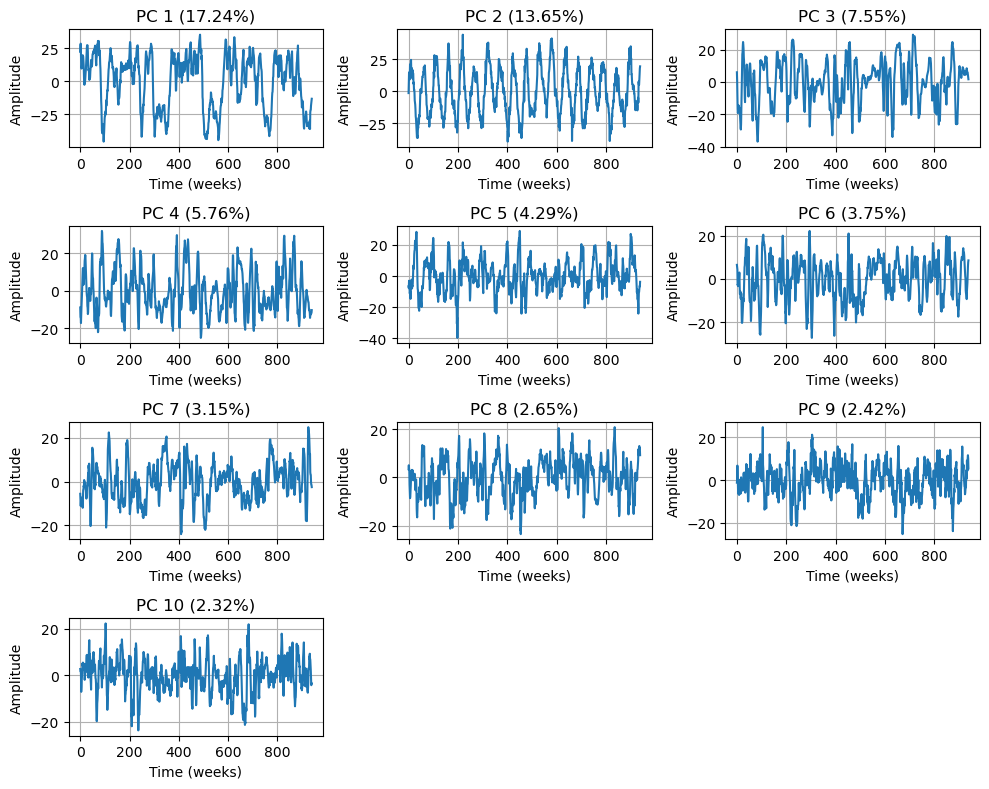

In [407]:
plt.figure(figsize=(10,8))

for i in range(k):
    plt.subplot(4, 3, i+1)
    plt.plot(PCs[:, i])
    plt.title(f'PC {i+1} ({np.round(explained[i] * 100, 2)}%)')
    plt.xlabel('Time (weeks)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

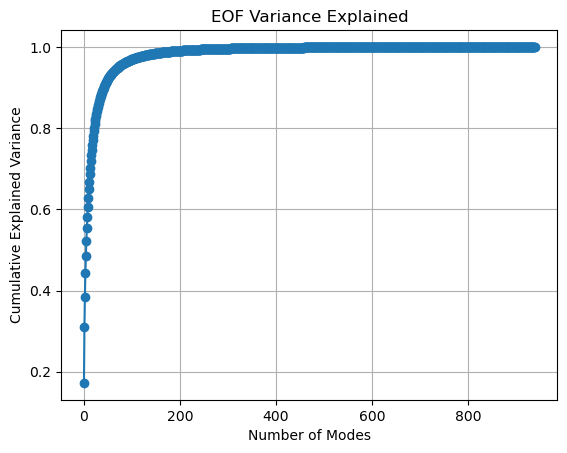

In [396]:
plt.figure()
plt.plot(cumm_var, marker='o')
plt.xlabel('Number of Modes')
plt.ylabel('Cumulative Explained Variance')
plt.title('EOF Variance Explained')
plt.grid(True)
plt.show()

### Discussion

The EOF modes represent dominant spatial patterns of sea surface height variability. EOF 1, with explained variance of 17.24%, captures the largest scale strucutre in the domain. From the plot, it looks like a broad, coherent pattern, likely representing a basin scale gradient or dominant circulation feature. EOF 2, with explained variance of 13.65%, shows a dipole like strucutre, which often indicates redistribution of water mass, like shifts in currents or pressure gradients. And higher modes, from EOF 3 to 10, shows increasingly localized and noisy patterns, representing smaller scale processes like eddies or transient features.

The PCs describe how each spatial mode evolves over time. PC 1 shows low frequency variability with some large swings, suggesting a longer term variabilityor regime shifts. PC 2 appears more oscillatory, likely capturing seasional or periodic behaviors. Higher PCs look increasingly noisy, representing short term or less organized variability. 

I decided to retain 10 nodes as, looking at the top 10, it explains about 62.8% of the data, and the cumulative variance plot shows that at around 10 nodes is when the difference becomes much smaller. The 10 modes capture a majority of the system's variability and avoides excess noise from higher modes.

EOF analysis helps to reduce dimensionality. While the original data had close to 300k spatial grid points, after EOF, only 10 time series remained. This enables easier modeling on principal components rather than the full fields, noise reduction by discarding low variance modes, and separation of spatial structure and temporal dynamics, which helps with forecasting.

## Task 4: Forecast the EOF Temporal Components

### Spliting SSH into Train and Test

In [640]:
horizon = 10 # Since we want to forecast 10 weeks, we want to trim the last 10 weeks
split = T - horizon
t_all = np.arange(T)
t_train = t_all[:split]
t_test = t_all[split:]

### 4.1 Model: ARMA/ARIMA

In [492]:
def select_d_adf(y, max_d=2, alpha=0.05):
    """
    selecting d using ADF test:
    - start at d=0
    - difference until stationary or max_d reached
    """
    for d in range(max_d + 1):
        if d == 0:
            y_test = y
        else:
            y_test = np.diff(y, n=d)

        try:
            pval = adfuller(y_test, autolag='AIC')[1]
        except Exception:
            continue

        if pval < alpha:
            return d, pval

    return max_d, pval  # fallback if never stationary

def fit_best_arima(y, pmax=2, d=0, qmax=2):
    """
    Grid-search ARIMA(p, d, q) using AIC
    - d=0 -> ARMA
    - d>0 -> ARIMA
    Returns (best_fit, (p, d, q))
    """
    best_aic, best_fit, best_order = np.inf, None, None
    
    for p in range(pmax + 1):
        for q in range(qmax + 1):
            if p == 0 and q == 0:
                continue
            try:
                fit = ARIMA(y, order=(p, d, q), trend='c').fit()
                if fit.aic < best_aic:
                    best_aic, best_fit, best_order = fit.aic, fit, (p, d, q)
            except Exception:
                continue
    return best_fit, best_order

def forecast_arima(y, steps=10, pmax=2, d=0, qmax=2):
    """
    Forecast using best ARIMA(p, d, q)
    -d=0 -> ARMA behavior
    """
    fit, order = fit_best_arima(y, pmax=pmax, d=d, qmax=qmax)
    
    fc = fit.get_forecast(steps=steps)
    mean = np.asarray(fc.predicted_mean)
    ci = np.asarray(fc.conf_int(alpha=0.05))
    
    return mean, ci, order, fit.aic

### 4.2 Model Kalman via UnobservedComponents

#### Kalman Filter A - Local Level Refactored

In [538]:
def kalman_local_level(y, steps=10, q=None, r=None):
    y = np.asarray(y, dtype=float)

    # noise estimation (more stable)
    dy = np.diff(y)
    var = np.var(dy) if len(dy) > 0 else 1.0
    if r is None: r = 0.5 * var
    if q is None: q = 0.1 * var   # smaller process noise → smoother

    n = len(y)
    x = np.zeros(n)
    P = np.zeros(n)

    x[0] = y[0]
    P[0] = var

    # filtering
    for k in range(1, n):
        # predict
        xp = y[-1]
        Pp = P[k-1] + q

        # update
        K = Pp / (Pp + r)
        x[k] = xp + K * (y[k] - xp)
        P[k] = (1 - K) * Pp

    # forecast
    x_fc = np.full(steps, x[-1])
    P_fc = P[-1] + q * np.arange(1, steps+1)

    std = np.sqrt(P_fc + r)
    ci = np.column_stack([x_fc - 1.96*std, x_fc + 1.96*std])

    return x_fc, ci, {"model": "local_level", "q": q, "r": r}

#### Kalman Filter B - Harmonic Refactored

In [542]:
def dominant_omega(y_train):
    """Angular frequency of the strongest non-DC FFT peak."""
    y   = y_train - np.mean(y_train)
    n   = len(y)
    Y   = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1.0)        # cycles per sample
    mag = np.abs(Y)
    mag[0] = 0                                # ignore DC
    k_peak = int(np.argmax(mag))
    f_peak = freqs[k_peak]
    return 2 * np.pi * f_peak, f_peak

def kalman_harmonic(y, steps=10, omega=None, q=1e-4, r=None):
    y = np.asarray(y, dtype=float)

    if omega is None:
        omega, _ = dominant_omega(y)

    dy = np.diff(y)
    var = np.var(dy) if len(dy) > 0 else 1.0
    if r is None: r = 0.5 * var

    c, s = np.cos(omega), np.sin(omega)
    F = np.array([[c, -s],
                  [s,  c]])
    H = np.array([[1.0, 0.0]])

    Q = np.eye(2) * q
    R = np.array([[r]])

    n = len(y)
    x = np.zeros((n, 2))
    P = np.zeros((n, 2, 2))

    x[0] = [y[0], 0.0]
    P[0] = np.eye(2) * var

    # filtering
    for k in range(1, n):
        x_pred = F @ x[k-1]
        P_pred = F @ P[k-1] @ F.T + Q

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T / S  # scalar inverse simplification

        innov = y[k] - (H @ x_pred)[0]
        x[k] = x_pred + (K.flatten() * innov)
        P[k] = (np.eye(2) - K @ H) @ P_pred

    # forecast
    x_fc = np.zeros((steps, 2))
    P_fc = np.zeros((steps, 2, 2))

    xp = np.array([y[-1], 0.0])
    Pp = P[-1].copy()

    for h in range(steps):
        xp = F @ xp
        Pp = F @ Pp @ F.T + Q
        x_fc[h] = xp
        P_fc[h] = Pp

    mean = x_fc[:, 0]
    std = np.sqrt(P_fc[:, 0, 0] + r)
    ci = np.column_stack([mean - 1.96*std, mean + 1.96*std])

    return mean, ci, {"model": "harmonic", "omega": omega}

#### Combining Kalman filter A and B

In [523]:
def forecast_kalman(y, steps=10):
    """
    Automatically choose Kalman model:
    - harmonic if strong periodic signal
    - otherwise local level
    """

    # detect dominant frequency
    omega, f = dominant_omega(y)

    # simple heuristic: strong periodic signal
    if f > 0.01:   # you can tune this threshold
        return kalman_harmonic(y, steps=steps, omega=omega)
    else:
        return kalman_local_level(y, steps=steps)

### Forecasting using Both Models

In [642]:
FORECAST_STEPS = 10
results = {}
for i in range(k):
    y = PCs[:, i]
    y_train = y[:split]
    y_test = y[split:]

    # ARIMA
    d, pval = select_d_adf(y)
    arima_mean, arima_ci, arima_order, arima_aic = forecast_arima(y_train, steps=FORECAST_STEPS, d=d)

    # Kalman
    kalman_mean, kalman_ci, kalman_info = forecast_kalman(y_train, steps=10)

    results[i] = dict(
        y=y, y_train=y_train, y_test=y_test,
        arima_forecast=arima_mean, arima_ci=arima_ci, arima_order=arima_order, arima_aic=arima_aic,
        kalman_forecast=kalman_mean, kalman_ci=kalman_ci, kalman_info=kalman_info
    )

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\ProgramData\anaconda3\Lib\site-packages\stat

In [668]:
def plot_pc_detail(i, r):    
    y_train, y_test = r["y_train"], r["y_test"]
    
    arima_fc = r["arima_forecast"]
    arima_ci = r["arima_ci"]
    arima_order = r["arima_order"]

    kf_fc = r["kalman_forecast"]
    kf_ci = r["kalman_ci"]
    kf_info = r["kalman_info"]

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, constrained_layout=True)

    # ARIMA Forecast
    ax = axes[0]
    ax.plot(t_train[800:], y_train[800:], lw=1.2, color="tab:gray", label="Train")
    ax.plot(t_test, y_test, lw=1.2, color="tab:gray", label="Test")
    ax.plot(t_test[:10], arima_fc, color="tab:blue", lw=2,
            label=f"Forecast ARIMA{arima_order}")
    ax.fill_between(t_test[:10], arima_ci[:, 0], arima_ci[:, 1], color="tab:blue", alpha=0.2, label="ARMIA 95% CI")
    ax.axvline(split, color="k", ls="--", lw=1)
    ax.set_title(f"PC{i+1}: Forecast ARIMA {arima_order}\n")
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(alpha=0.3)

    # Kalman Forecast
    ax = axes[1]
    ax.plot(t_train[800:], y_train[800:], lw=1.2, color="tab:gray", label="Train")
    ax.plot(t_test, y_test, lw=1.2, color="tab:gray", label="Test")
    ax.plot(t_test[:10], kf_fc, color="tab:orange", lw=2,
        label=f"Kalman ({kf_info['model']})")
    ax.fill_between(t_test[:10], kf_ci[:, 0], kf_ci[:, 1], color="tab:orange", alpha=0.2)
    ax.axvline(split, color="k", ls="--", lw=1)
    ax.set_title(f"\nPC{i+1}: Forecast Kalman {kf_info['model']}\n")
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.suptitle(f"PC{i+1}: ARIMA vs Kalman Forecast\n")
    plt.show()

Graph Starting from Week 800 to Zoom in on the Forecast


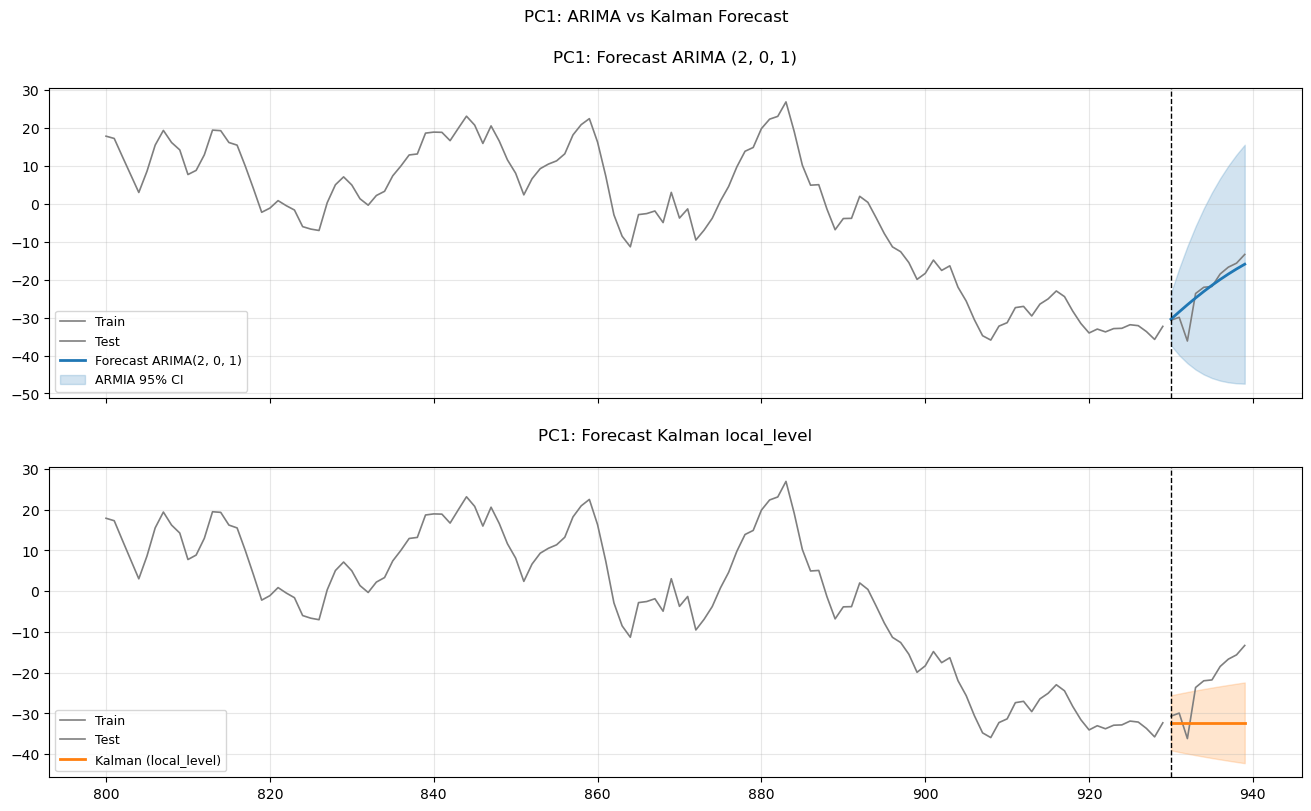

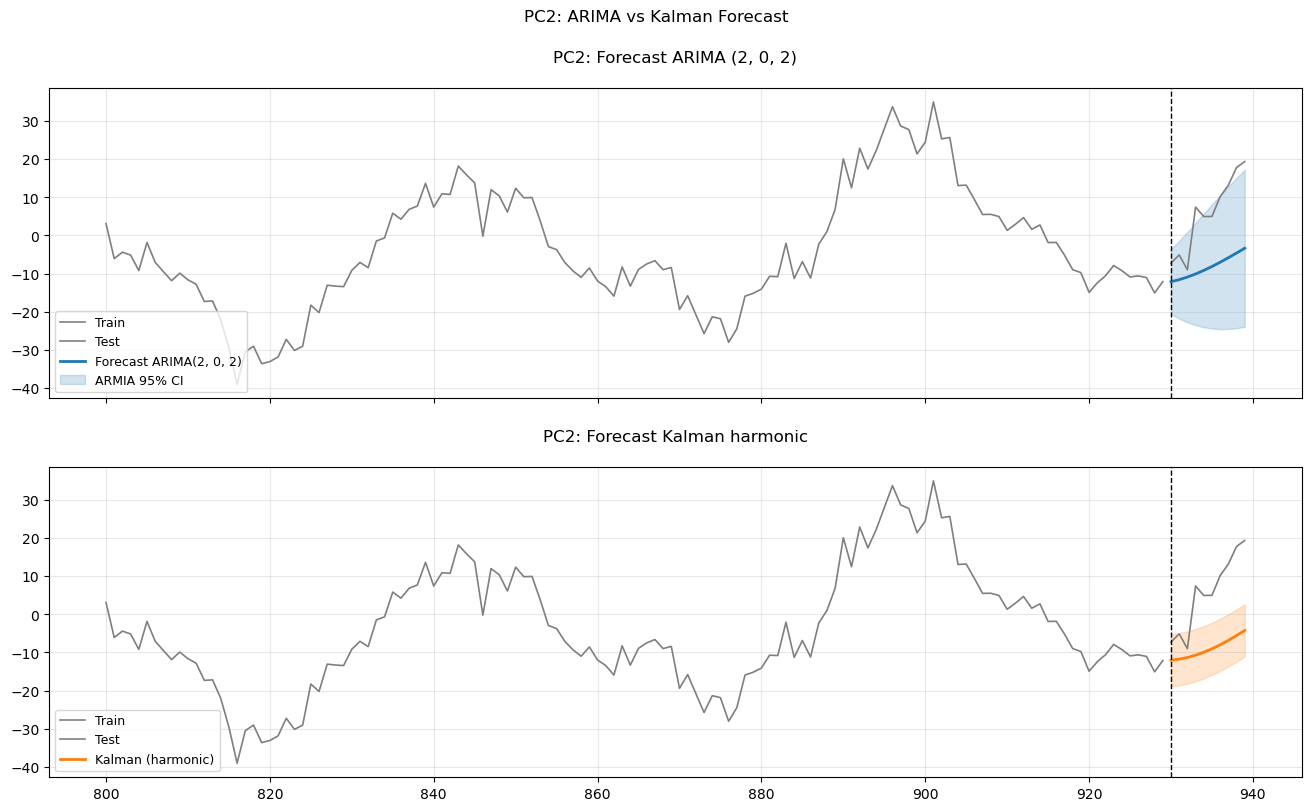

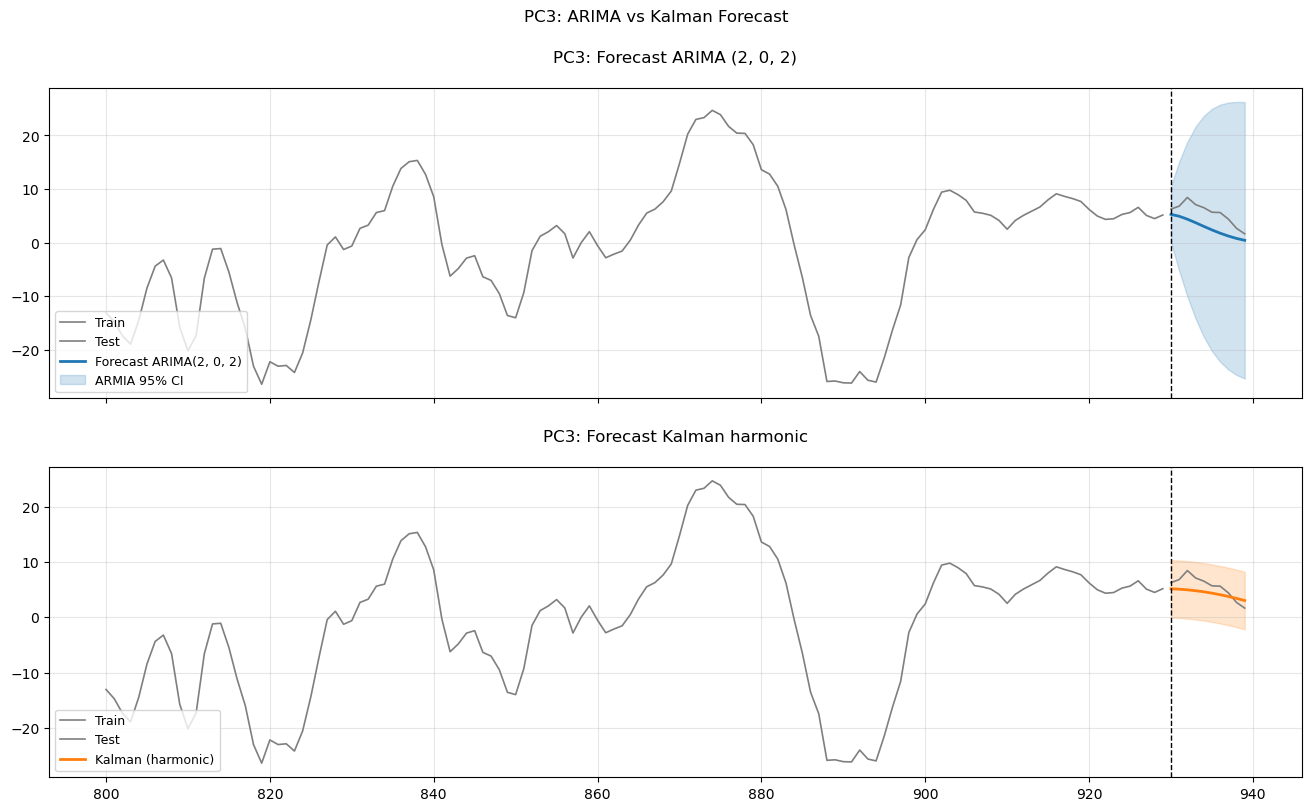

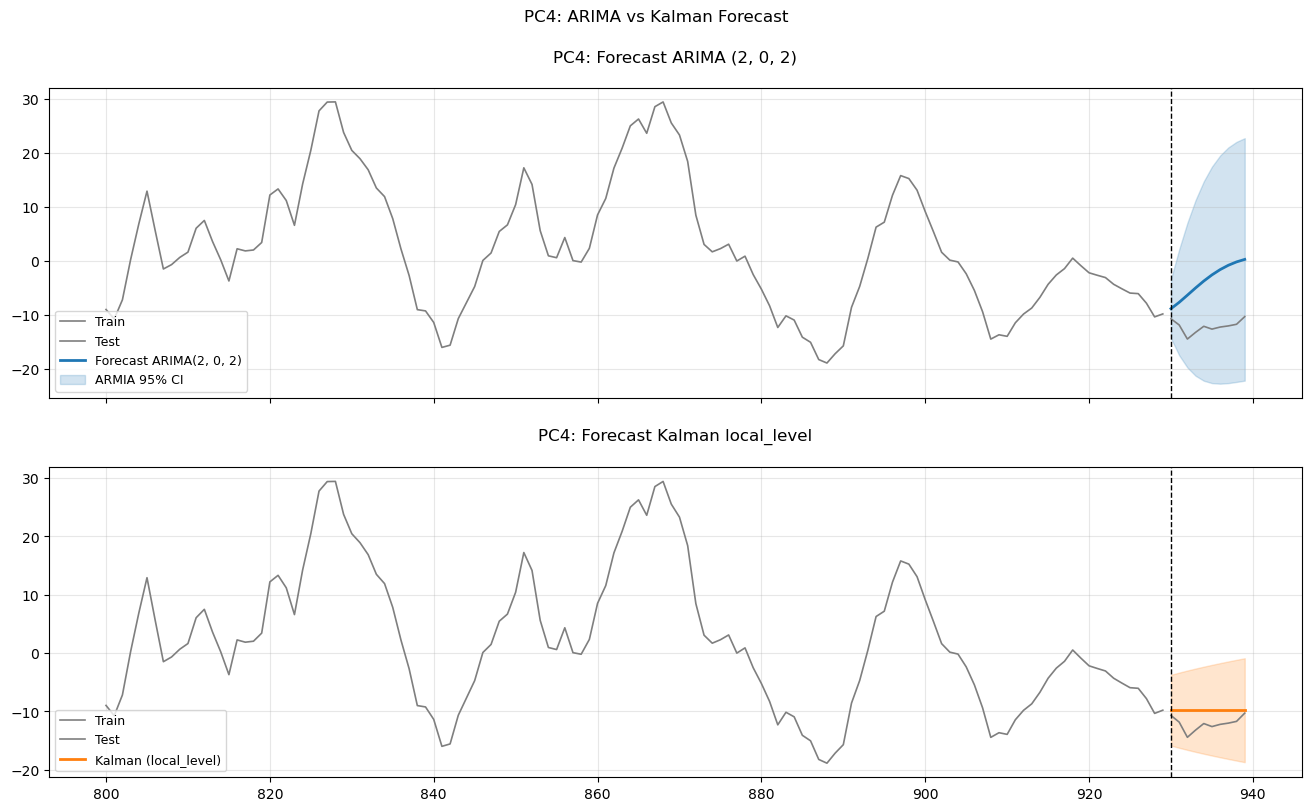

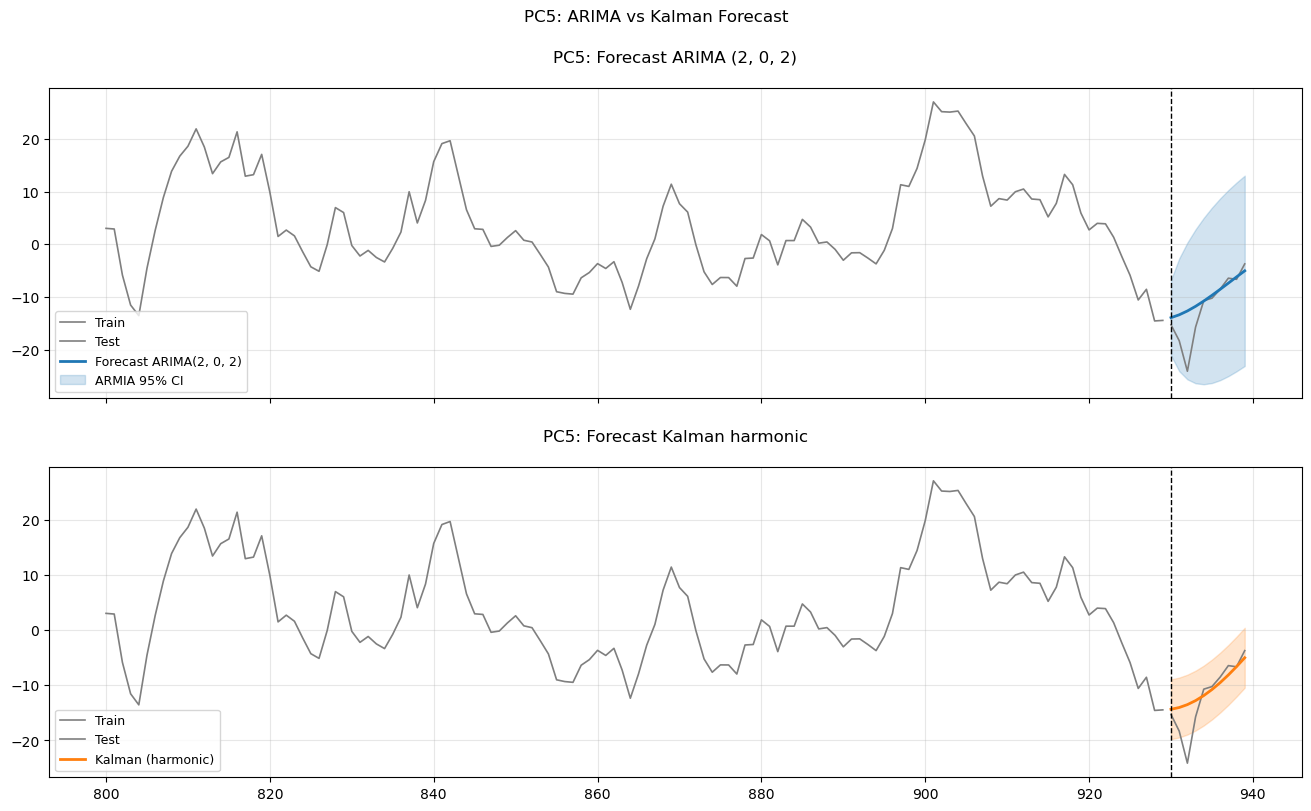

In [672]:
print("Graph Starting from Week 800 to Zoom in on the Forecast")
for i in range(5):
    plot_pc_detail(i, results[i])

### Discussion

**ARMA Model**

The autoregressive component models the current value of a principal component as a function of its past values:

$x_t = \sum_{i=1}^{p} \phi_i x_{t-i} + \epsilon_t$

with the coefficients $\phi_i$ quantifying how strongly previous weeks influence the current week. This part of the model captures the temporal persistence in the system.

The moving average componenet models the current value as a function of past random errors:

$x_t = \sum_{j=1}^{q} \theta_j \epsilon_{t-j} + \epsilon_t$

with the coefficients $\theta_j$ describing how past forecast errors influence the present. This part of the model captures short term corrections and noise structure.

ARAM is appropriate when the PC time series is stationary, meaning its mean and variance are approximately constant over time and there are no strong trneds or long term drift, non-seasonal, with no strong periodic behaviors, and dominated by short term temporal dependence, meaning its current values depend mainly on recent past values and noise.

**ARIMA Model**

An ARIMA model combines the autoregression and moving average components with a third componenet called differencing. In regards to ARIMA, p represents the autoregressive order, defined as the number of past values used to predict the current value, q represents the moving average order, defined as the number of past error terms included, and d represents the degree of differencing, defined as the number of times the series is differenced to achieve stationarity, and this is the main distinguisher between ARIMA to ARMA.

Differeencing removes non stationary components such as trends or slow variations. With each subsequent differencing, it removes long-term trends or drifts, stabilizes the mean over time, and reduces low frequency variability.

ARIMA is preferred when the time series is not stationary in its original form. You should use ARIMA if the PC shows trends, drifts, or low frequency variability, if the mean changes over time, or ADF test indicates non stationarity. You can use ARMA is the PC is stationary, mean reverting, and does not have strong trends.

**Kalman Filters Model**

A Kalman filter models the system using 2 equations:

The state equation: $z_t = A z_{t-1} + w_t$

with $z_t$ being the hidden state, $A$ being the state transition matrix, and $w_t$ being the process noise. This step predicts the next state based on the previous one. 

The observation equation: $y_t = H z_t + v_t$

with $y_t$ being the observed data, $H$ being the observed matrix, and $v_t$ being the observed noise. This step corrects the prediction using the actual observation.

Overall, the filter continuously predicts, corrects, and then repeats through a recursive process using the 2 equations above.

Geophysical data like SSH contains measurement noise, exhibit time varying dynamics, and often include hidden processes. Kalman filter is useful because it separates signal from noise by producing a smoothed estimate of the true state and handles missing or irregular data since the prediction step still works even without observation.

The Kalman filter provides a recursive, state space framework that separates signal from noise and adapts over time, making it particularly well suited for forecasting noisy and dynamicaly evolving SSH principal components compared to ARMA and ARIMA models.

## Task 5: Reconstruct the Forecasted Weekly SSH Field

In [768]:
def reshape_field(pc):
    X_mean = np.mean(SSH_valid, axis=0)
    X_full = np.full((FORECAST_STEPS, M), np.nan)
    X_full[:, valid_mask] = pc @ EOFs + X_mean
    return X_full.reshape(FORECAST_STEPS, Nlat, Nlon)

In [770]:
# ARIMA
A_hat_arima = np.stack([results[i]['arima_forecast'] for i in range(k)], axis=1)
SSH_arima = reshape_field(A_hat_arima)

A_hat_kf = np.stack([results[i]['kalman_forecast'] for i in range(k)], axis=1)
SSH_kf = reshape_field(A_hat_kf)

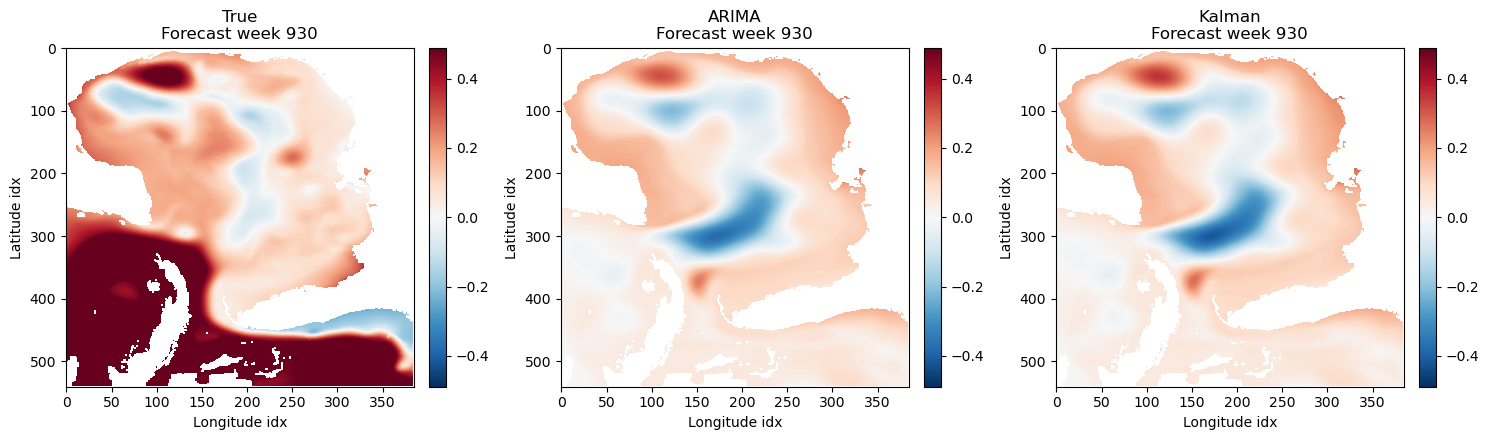

In [772]:
vmax = np.nanmax(np.abs([SSH_arima, SSH_kf]))
kwargs = dict(cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, field, title in zip(axes,
                            [SSH[split], SSH_arima[0], SSH_kf[0]],
                            ["True", "ARIMA", "Kalman"]):
    im = ax.imshow(field, **kwargs)
    ax.set_title(f"{title}\nForecast week {split}")
    ax.set_xlabel("Longitude idx"); ax.set_ylabel("Latitude idx")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Discussion

Both Arima and Kalman reconstructions capture the central dipole like structure and the location of dominant features is reasonably consistent with the true field. However, the forecasts lose amplitude and sharpness where the extremes are weaker, indicated by duller colors, and fine scale features present in the true field are largely missing. This, at least, indicates that the dominant EOF modes successfully retained coarse spatial variability. 

Forecasting in EOF space was largely effective with some limitations. The dimensionality reduction allowed modeling only a few PCs instead of thousands of grid points, and it was still able to capture the dominant variability patterns and produce a physically interpretable spatial field. However, its limitations were that the forecasts were overly smooth and the variability was damped, especialy for ARIMA. In our case, the Kalman model performed slightly better by retaining more structure, whereas the ARIMA model tended to revert towards the mean, giving flatter results.

EOF based forebasting effectively preserves large scale spatial patterns but struggles to capture high variability regions and fine scale structures, with errors primarily arising from inaccuracies in forecasting higher order principal components. 

## Task 6: Evaluate and Compare the Models

In [801]:
def rmse(a, b):
    diff = a - b
    return np.sqrt(np.nanmean(diff**2))

def mae(a, b):
    return np.nanmean(np.abs(a - b))

def corr(a, b):
    a_flat = a.reshape(-1)
    b_flat = b.reshape(-1)

    mask = ~np.isnan(a_flat) & ~np.isnan(b_flat)

    return np.corrcoef(a_flat[mask], b_flat[mask])[0,1]

# Last 10 weeks of Truth
PC_true = PCs[-horizon:, :]
SSH_true = SSH[-horizon:, :, :]

print(PC_true.shape)
print(SSH_true.shape)

(10, 10)
(10, 541, 385)


### True vs Predicted PCs

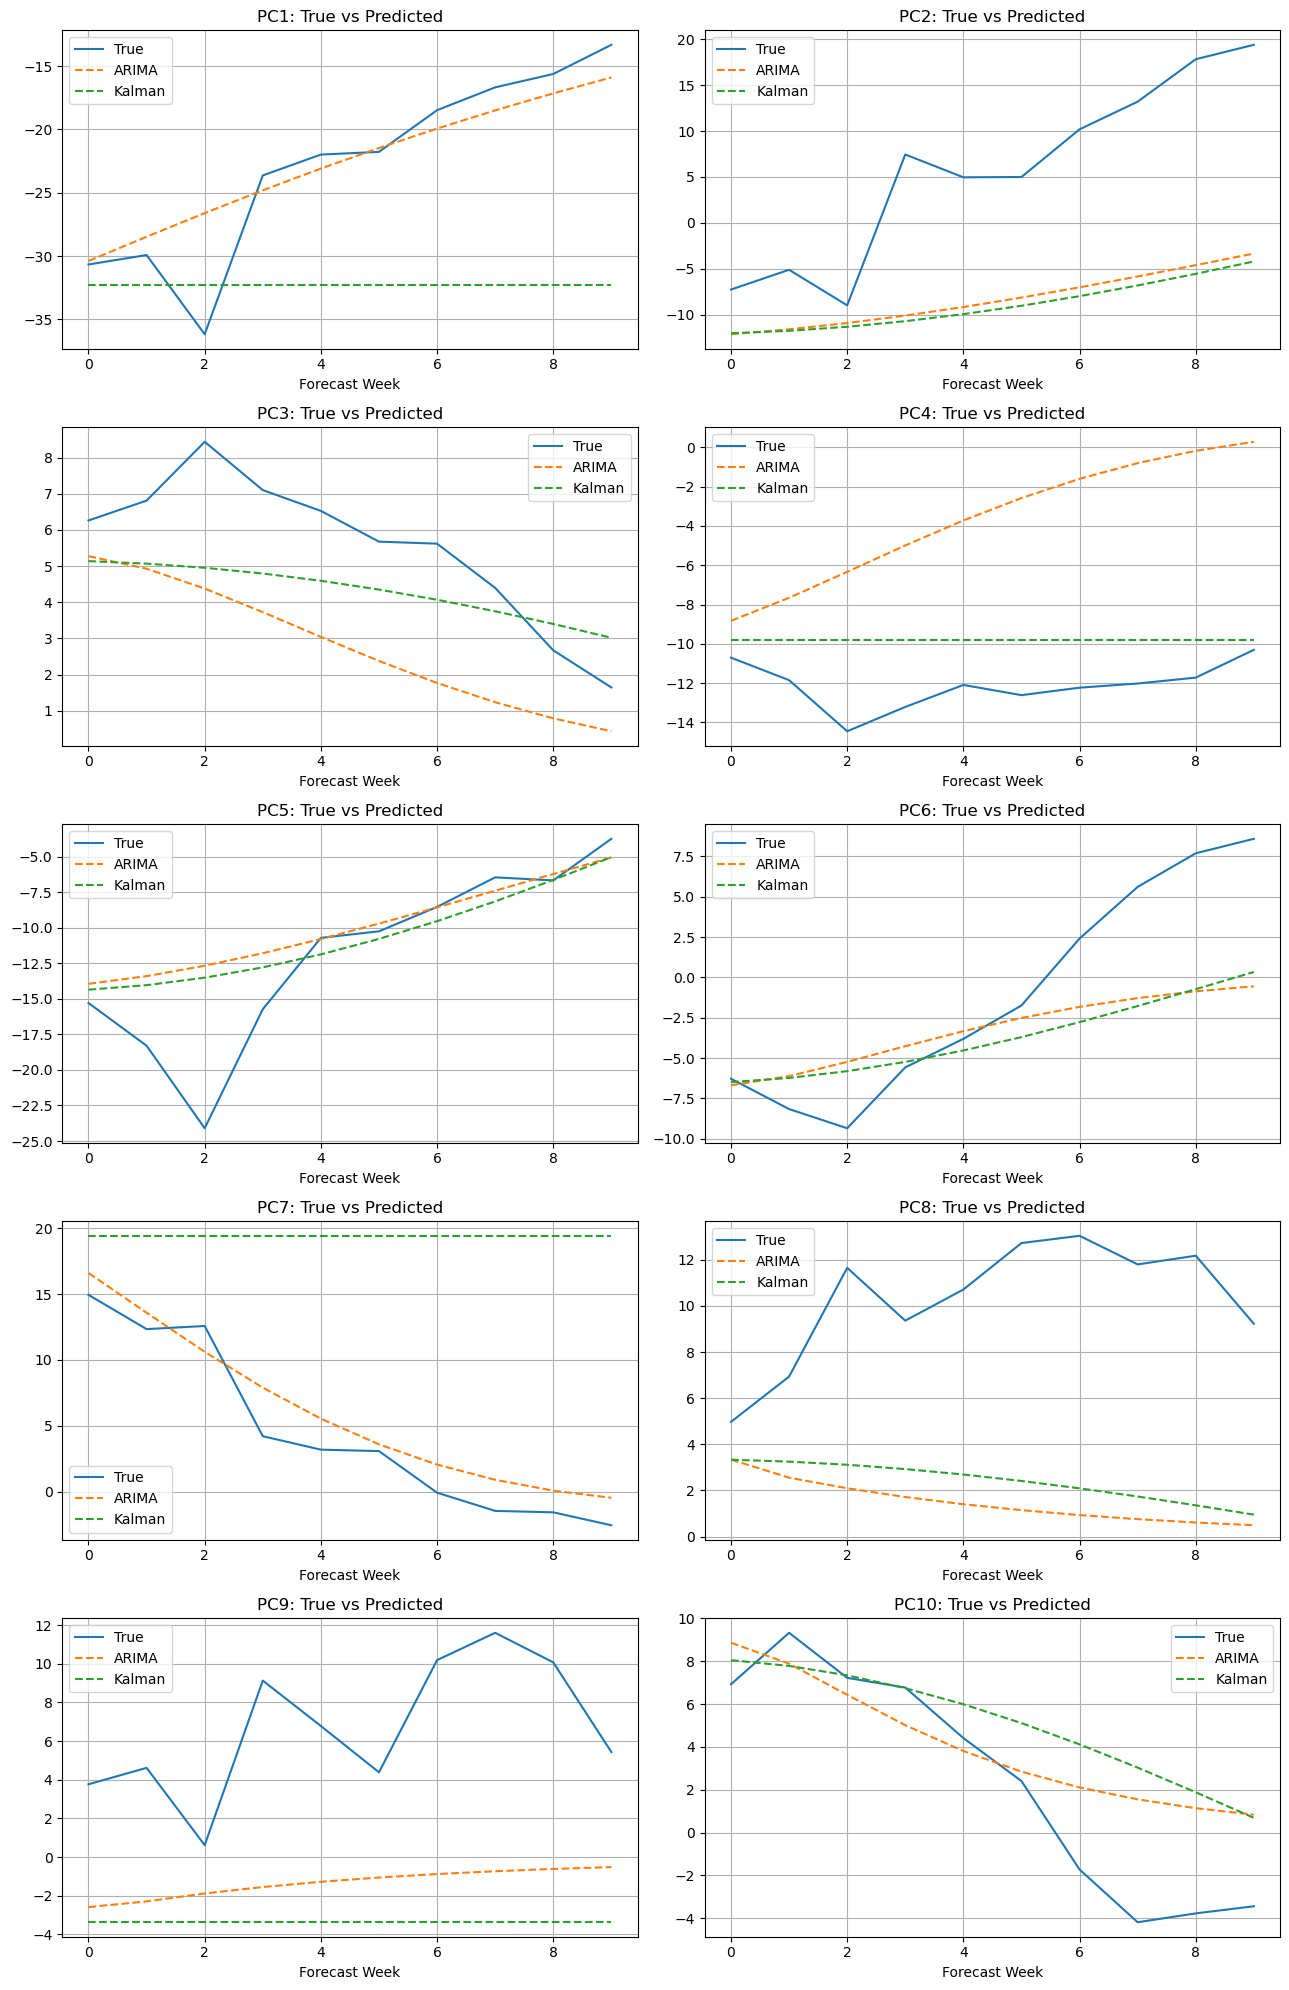

In [799]:
metrics_pc = {}

metrics_pc['ARIMA'] = {
    "RMSE": rmse(A_hat_arima, PC_true),
    "MAE": mae(A_hat_arima, PC_true),
    "CORR": corr(A_hat_arima, PC_true)
}

metrics_pc['Kalman'] = {
    "RMSE": rmse(A_hat_kf, PC_true),
    "MAE": mae(A_hat_kf, PC_true),
    "CORR": corr(A_hat_kf, PC_true)
}

plt.figure(figsize=(13, 20))
for i in range(k):
    plt.subplot(5, 2, i+1)
    plt.plot(PC_true[:, i], label='True')
    plt.plot(A_hat_arima[:, i], '--', label='ARIMA')
    plt.plot(A_hat_kf[:, i], '--', label='Kalman')
    
    plt.title(f'PC{i+1}: True vs Predicted')
    plt.xlabel('Forecast Week')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

### True vs Predicted SSH

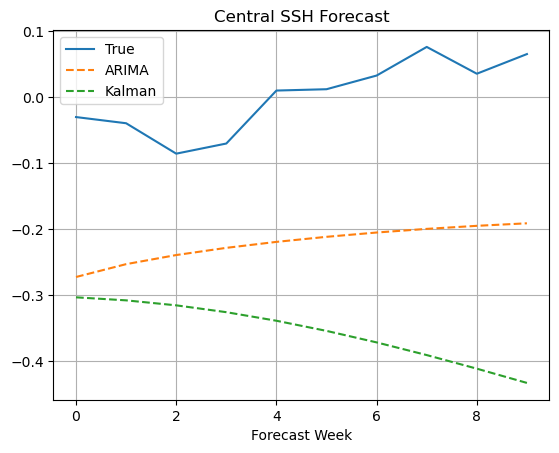

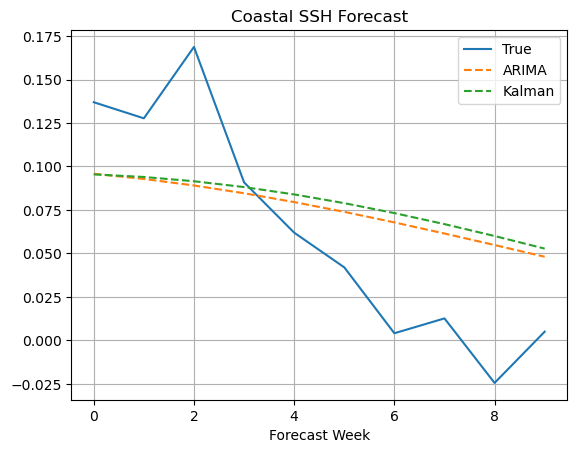

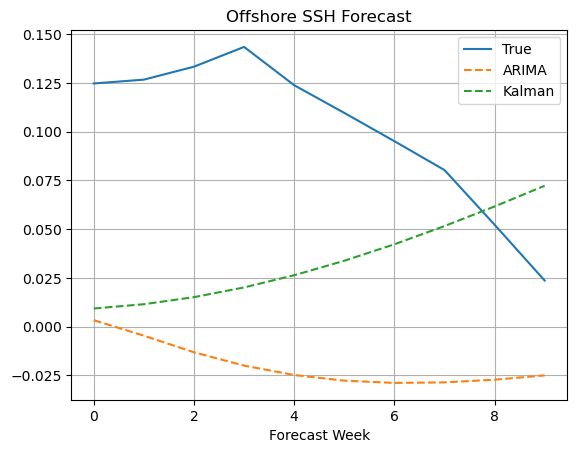

In [805]:
metrics_ssh = {}

metrics_ssh['ARIMA'] = {
    "RMSE": rmse(SSH_arima, SSH_true),
    "MAE": mae(SSH_arima, SSH_true),
    "CORR": corr(SSH_arima, SSH_true)
}

metrics_ssh['Kalman'] = {
    "RMSE": rmse(SSH_kf, SSH_true),
    "MAE": mae(SSH_kf, SSH_true),
    "CORR": corr(SSH_kf, SSH_true)
}

points = {
    "Central": (Nlat//2, Nlon//2),
    "Coastal": (Nlat // 15, Nlon // 2),
    "Offshore": (Nlat // 4, Nlon // 2)
}

for name, (i, j) in points.items():
    plt.figure()

    plt.plot(SSH_true[:, i, j], label='True')
    plt.plot(SSH_arima[:, i, j], '--', label='ARIMA')
    plt.plot(SSH_kf[:, i, j], '--', label='Kalman')

    plt.title(f'{name} SSH Forecast')
    plt.xlabel('Forecast Week')
    plt.legend()
    plt.grid(True)
    plt.show()

### Error over Forecast Week

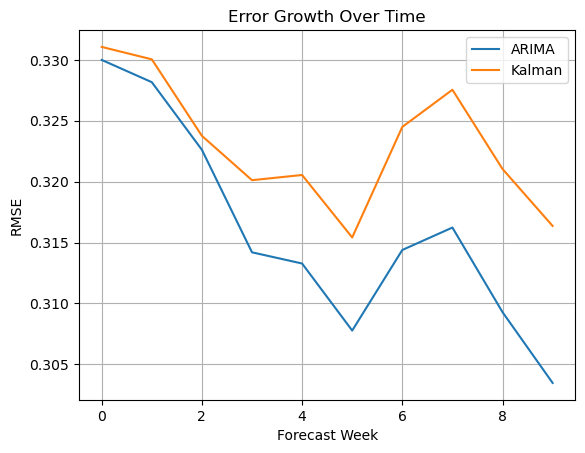

In [807]:
rmse_arima_time = []
rmse_kf_time = []

for t in range(k):
    rmse_arima_time.append(rmse(SSH_arima[t], SSH_true[t]))
    rmse_kf_time.append(rmse(SSH_kf[t], SSH_true[t]))

plt.figure()
plt.plot(rmse_arima_time, label='ARIMA')
plt.plot(rmse_kf_time, label='Kalman')

plt.xlabel('Forecast Week')
plt.ylabel('RMSE')
plt.title('Error Growth Over Time')
plt.legend()
plt.grid(True)
plt.show()

### Map based Comparison

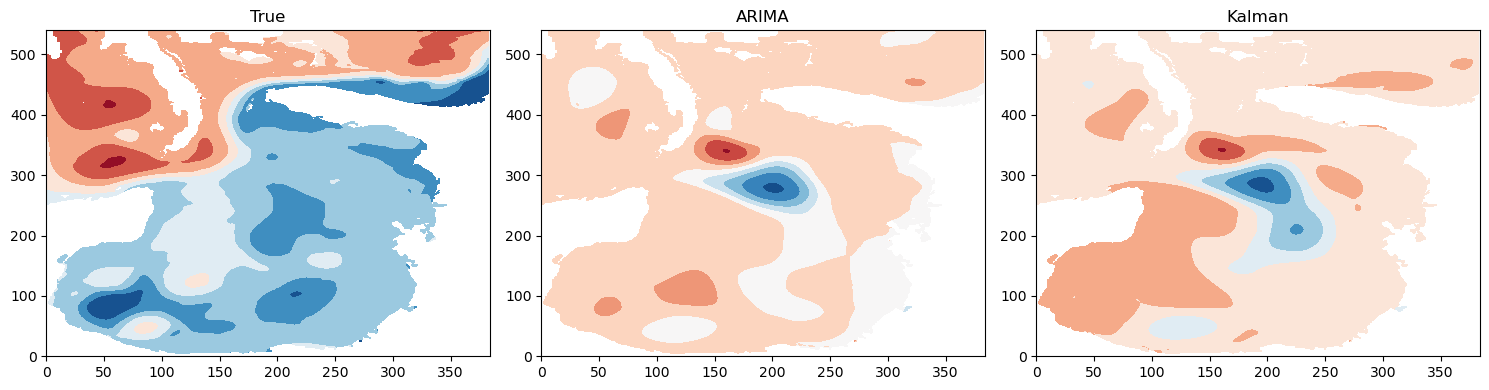

In [810]:
w = 4  # choose a week

fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].contourf(Lon, Lat, SSH_true[w], cmap='RdBu_r')
axes[0].set_title('True')

axes[1].contourf(Lon, Lat, ssh_arima[w], cmap='RdBu_r')
axes[1].set_title('ARIMA')

axes[2].contourf(Lon, Lat, ssh_kf[w], cmap='RdBu_r')
axes[2].set_title('Kalman')

plt.tight_layout()
plt.show()

### Discussion

ARIMA slightly outperformed the Kalman filter in this study, particularly in capturing trend behavior, although both methods exhibited increasing error with forecast horizon. While EOF based forecasting effectively preserves large scale spatial patterns, it stuggles with smaller scale variability and oscillatory dynamics, highlighting limitations of linear models for weekly ocean SSH prediction.

## Task 7: Discussion and Insights

1. The leading EOF modes captured large scale basin wide variability, including dipole like structures and central gradients in SSH. These modes represent dominant circulation patterns, while higher modes captured localized and noisier features.

2. Removing trends and seasonal components improved model performance by making PCs more stationary and predictable. However, residual periodic behaviors still limited models like ARIMA that do not explicitly handle seasonality.

3. ARIMA performed slightly better overall, as it captured trend behavior and temporal persistence more effectively. The Kalman filter produced smoother forecasts but tended to underestimate variability and drift from true values.

4. For ARMA, it was simple and effectve for stationary PCs, but fails when trends or non stationarity are present. For ARIMA, it handles non stationarity through differencing, but often damps variability and struggles with periodic signals. For Kalman filter, it is flexible and noise aware, but can produce overly smooth forecasts and requires careful model specification.

5. This workflow can be applied to systems like sea surface temperature prediction or environmental monitoring by combining dimensionality reduction (EOF/PCA) with time series forecasting. It is especially useful for high dimensional spatiotemporal data where dominant patters can be isolated and predicted efficiently.

6. For future work, possibly using a multivariate model and adding more explanatory variables like wind, temperature, or atmospheric indices to improve predictive skils. By adding more variables, it will help to capture more interactions between different modes.